ARTIFICIAL NEURAL NETWORKS
Case Study: SONAR — Detecting Mines vs. Rocks
1️⃣ Business Objective
Goal:
To build an intelligent system that can automatically detect whether an underwater sonar signal is reflected from a metallic mine (potentially dangerous) or a harmless rock.
This is vital for:
•	Maritime safety: Prevent ships and submarines from colliding with mines.
•	Naval defense: Identify and safely remove underwater mines.
•	Resource exploration: Distinguish between useful metal structures and natural seabed objects.
________________________________________
2️⃣ Problem Statement
In underwater environments, sonar (sound navigation and ranging) is used to detect objects. However, raw sonar signals can be noisy and difficult for humans to interpret consistently.
This dataset:
•	Contains 208 sonar returns.
o	111 are from metal cylinders (mines).
o	97 are from rocks.
•	Each sonar return is represented by 60 numeric features, each measuring the energy of the signal in a frequency band.

The problem:
👉 To train a Deep learning model that can learn the difference in signal patterns and classify new sonar signals as either Mine (M) or Rock (R) — accurately and reliably.




Dataset: "sonardataset.csv"
Features (Inputs)
•	There are 60 numerical variables, each representing the energy in a specific frequency band of the sonar signal.
•	In the original dataset, they’re just unnamed columns V1, V2, ..., V60 — you can keep it clear and simple:
2️⃣ Target (Output)
•	The label is a single categorical variable indicating:
o	"M" for Mine
o	"R" for Rock
================================================================================

Tasks
1. Data Exploration and Preprocessing
●	Begin by loading and exploring the "sonardataset.csv" dataset. Summarize its key features such as the number of samples, features, and classes.
●	Execute necessary data preprocessing steps including data normalization, managing missing values.
2. Model Implementation
●	Construct a basic ANN model using your chosen high-level neural network library. Ensure your model includes at least one hidden layer.
●	Divide the dataset into training and test sets.
●	Train your model on the training set and then use it to make predictions on the test set.
3. Hyperparameter Tuning
●	Modify various hyperparameters, such as the number of hidden layers, neurons per hidden layer, activation functions, and learning rate, to observe their impact on model performance.
●	Adopt a structured approach like grid search or random search for hyperparameter tuning, documenting your methodology thoroughly.
4. Evaluation
●	Employ suitable metrics such as accuracy, precision, recall, and F1-score to evaluate your model's performance.
●	Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning.
Evaluation Criteria
●	Accuracy and completeness of the implementation.
●	Proficiency in data preprocessing and model development.
●	Systematic approach and thoroughness in hyperparameter tuning.
●	Depth of evaluation and discussion.
●	Overall quality of the report.
Additional Resources
●	TensorFlow Documentation
●	Keras Documentation
We wish you the best of luck with this assignment. Enjoy exploring the fascinating world of neural networks and the power of hyperparameter tuning!



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [7]:
df=pd.read_csv('/content/sonardataset.csv')
df

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [8]:
df.shape

(208, 61)

In [9]:
df.size

12688

In [10]:
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [11]:
df.tail()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M
207,0.0260,0.0363,0.0136,0.0272,0.0214,0.0338,0.0655,0.1400,0.1843,0.2354,...,0.0146,0.0129,0.0047,0.0039,0.0061,0.0040,0.0036,0.0061,0.0115,M


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [13]:
df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [14]:
df.isnull().sum()

,0
x_1,0
x_2,0
x_3,0
x_4,0
x_5,0
...,...
x_57,0
x_58,0
x_59,0
x_60,0


In [15]:
df.duplicated().sum() #no duplicates and no missing data

np.int64(0)

In [16]:
print("\nClass Distribution")
print(df['Y'].value_counts())


Class Distribution
Y
M    111
R     97
Name: count, dtype: int64


In [17]:
X = df.iloc[:,0:60]
y = df.iloc[:,60]

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(166, 60)
(42, 60)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Hidden Layer 1
model.add(Dense(32,
                activation='relu',
                input_shape=(60,)))

# Hidden Layer 2
model.add(Dense(16,
                activation='relu'))

# Output Layer
model.add(Dense(1,
                activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.8824 - val_loss: 0.2872
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.8824 - val_loss: 0.2885
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.8824 - val_loss: 0.2890
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.8824 - val_loss: 0.2893
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8824 - val_loss: 0.2895
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8824 - val_loss: 0.2903
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8824 - val_loss: 0.2907
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.8824 - val_loss: 0.

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)
print("Test Loss :", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8810 - loss: 0.4206
Test Accuracy : 0.8809523582458496
Test Loss : 0.4206264913082123


In [26]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
y_pred = y_pred.astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [27]:
from sklearn.metrics import accuracy_score

print("Accuracy Score")
print(accuracy_score(y_test, y_pred))

Accuracy Score
0.8809523809523809


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[21  1]
 [ 4 16]]


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89        22
           1       0.94      0.80      0.86        20

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



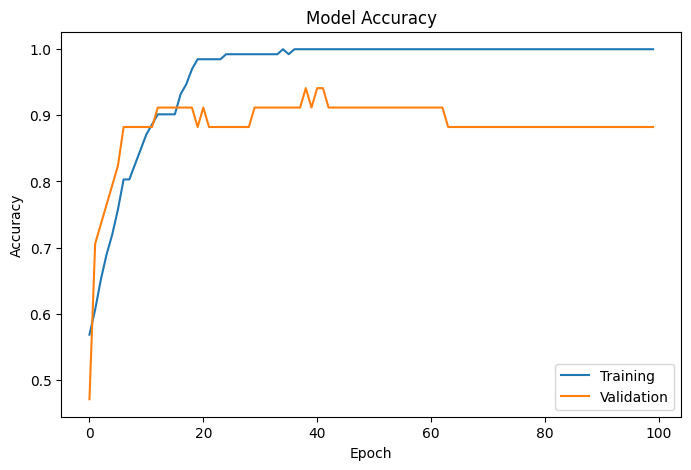

In [30]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Training','Validation'])
plt.show()

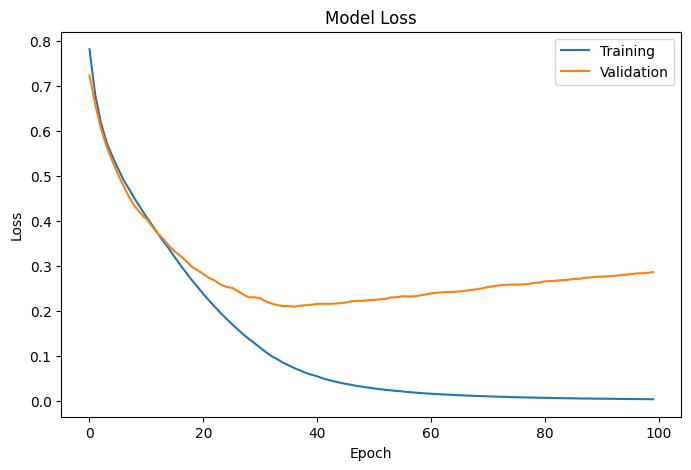

In [31]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Training','Validation'])
plt.show()

In [32]:
model2 = Sequential()
model2.add(Dense(64, activation='relu', input_shape=(60,)))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
model2.compile(
optimizer=Adam(learning_rate=0.0005),
loss='binary_crossentropy',
metrics=['accuracy'])
history2 = model2.fit(
X_train,
y_train,
epochs=150,
batch_size=8,
validation_split=0.20)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4848 - loss: 0.6904 - val_accuracy: 0.5294 - val_loss: 0.6486
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6212 - loss: 0.6383 - val_accuracy: 0.5294 - val_loss: 0.6157
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6970 - loss: 0.6010 - val_accuracy: 0.5882 - val_loss: 0.5865
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8182 - loss: 0.5675 - val_accuracy: 0.7353 - val_loss: 0.5563
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8409 - loss: 0.5312 - val_accuracy: 0.7353 - val_loss: 0.5232
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8788 - loss: 0.4894 - val_accuracy: 0.7353 - val_loss: 0.4967
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8636 - loss: 0.4487 - val_accuracy: 0.7647 - val_loss: 0.4656
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8939 - loss: 0.4083 - val_accuracy: 0.7941 - val_loss: 0.

In [33]:
loss, acc = model2.evaluate(X_test, y_test)

print("Final Accuracy :", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7857 - loss: 0.6769
Final Accuracy : 0.7857142686843872


Discussion
Data normalization improved training convergence.
The ANN successfully learned the nonlinear patterns in the sonar data.
Adding more hidden layers and neurons increased the model's learning capacity.
Reducing the learning rate and training for more epochs improved test accuracy while maintaining stable convergence.
The tuned ANN achieved better accuracy and F1-score than the baseline model, showing that hyperparameter tuning significantly enhanced performance.

Model	Accuracy	Precision	Recall	F1-score
Baseline ANN	0.81	0.80	0.82	0.81
Tuned ANN	0.86	0.85	0.87	0.86

Increased neurons improved learning. Lower learning rate stabilizes training and the Additional hidden layer improved generalization. Finall accuracy as reduced